In [2]:
! pip3 install pymysql
! pip3 install ipython-sql
! pip3 install mysqlclient

In [10]:
! pip3 install pandas

     ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
     ---------------------------------------- 0.0/10.6 MB 1.4 MB/s eta 0:00:08
     --------------------------------------- 0.1/10.6 MB 787.7 kB/s eta 0:00:14
     --------------------------------------- 0.1/10.6 MB 819.2 kB/s eta 0:00:13
      -------------------------------------- 0.2/10.6 MB 952.6 kB/s eta 0:00:11
      -------------------------------------- 0.2/10.6 MB 952.6 kB/s eta 0:00:11
      -------------------------------------- 0.2/10.6 MB 952.6 kB/s eta 0:00:11
      -------------------------------------- 0.2/10.6 MB 952.6 kB/s eta 0:00:11
     - ------------------------------------- 0.4/10.6 MB 969.8 kB/s eta 0:00:11
     - -------------------------------------- 0.4/10.6 MB 1.0 MB/s eta 0:00:10
     - -------------------------------------- 0.5/10.6 MB 1.1 MB/s eta 0:00:10
     - -------------------------------------- 0.5/10.6 MB 1.0 MB/s eta 0:00:10
     -- ------------------------------------- 0.5/10

In [20]:
! pip3 install matplotlib

     ---------------------------------------- 0.0/7.6 MB ? eta -:--:--
     ---------------------------------------- 0.1/7.6 MB 1.3 MB/s eta 0:00:06
      --------------------------------------- 0.1/7.6 MB 1.4 MB/s eta 0:00:06
     - -------------------------------------- 0.2/7.6 MB 1.5 MB/s eta 0:00:06
     - -------------------------------------- 0.3/7.6 MB 1.4 MB/s eta 0:00:06
     - -------------------------------------- 0.3/7.6 MB 1.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.4/7.6 MB 1.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.5/7.6 MB 1.3 MB/s eta 0:00:06
     -- ------------------------------------- 0.5/7.6 MB 1.4 MB/s eta 0:00:06
     -- ------------------------------------- 0.6/7.6 MB 1.4 MB/s eta 0:00:06
     --- ------------------------------------ 0.6/7.6 MB 1.4 MB/s eta 0:00:06
     --- ------------------------------------ 0.7/7.6 MB 1.4 MB/s eta 0:00:06
     ---- ----------------------------------- 0.8/7.6 MB 1.4 MB/s eta 0

In [8]:
# import libraries
import os
from sqlalchemy import create_engine
import pymysql
import pandas as pd
#import mysql.connector

In [46]:
# inisiasi attributes

db_name = "penjualan"
db_host = "localhost"
db_username = "root"
db_password = ""

# make the database connection

try:
    conn = pymysql.connect(host = db_host,
                          port = int(3306),
                          user = 'root',
                          passwd = db_password,
                          db = db_name)
except e:
    print(e)
    
if conn:
    print("Successfully Connected")
else:
    print("Error")
    
# activate magic function

%load_ext sql
%sql mysql+mysqldb://root@localhost

Successfully Connected
The sql extension is already loaded. To reload it, use:
  %reload_ext sql


In [45]:
%%sql 
create schema penjualan;
use penjualan;

 * mysql+mysqldb://root@localhost
1 rows affected.
0 rows affected.


[]

In [65]:
data = pd.read_csv("D:\coolyeah\SEMESTER 4\BasDat\Data2.csv", nrows=20)
data = data.rename(columns={'  num_pages': 'num_pages'})
data.head()

,No,Tanggal,Kode_Pelanggan,Nama_Pelanggan,Kode_Produk,Nama_Produk,Qty,Harga_Satuan,Total_Penjualan,Diskon,Penjualan_Bersih
0,1,1-Aug,NF-01,Toko Nofri,B-05,Besi 5 Meter,340,200000,68000000,0.1,61200000
1,2,1-Aug,AN-02,Toko Anton,B-10,Besi 10 Meter,140,375000,52500000,0.0,52500000
2,3,1-Aug,CT-03,Toko Central,P-5,Pipa 5 Meter,560,100000,56000000,0.2,44800000
3,4,2-Aug,CT-03,Toko Central,P-10,Pipa 10 Meter,230,185000,42550000,0.1,38295000
4,5,2-Aug,AN-02,Toko Anton,B-05,Besi 5 Meter,770,200000,154000000,0.2,123200000


In [78]:
#normalisasi tabel pelanggan
pelanggan = data[['Kode_Pelanggan', 'Nama_Pelanggan']].drop_duplicates('Kode_Pelanggan').reset_index(drop=True)

#normalisasi table produk
produk = data[['Kode_Produk', 'Nama_Produk', 'Harga_Satuan']].drop_duplicates('Kode_Produk').reset_index(drop=True)

#normalisasi table transaksi
transaksi = data [['Tanggal', 'Kode_Pelanggan', 'Kode_Produk', 'Qty', 'Total_Penjualan', 'Diskon', 'Penjualan_Bersih']]
transaksi.insert(0, 'Kode_Transaksi', '')

In [75]:
pelanggan.head()

,Kode_Pelanggan,Nama_Pelanggan
0,NF-01,Toko Nofri
1,AN-02,Toko Anton
2,CT-03,Toko Central


In [76]:
produk.head()

,Kode_Produk,Nama_Produk,Harga_Satuan
0,B-05,Besi 5 Meter,200000
1,B-10,Besi 10 Meter,375000
2,P-5,Pipa 5 Meter,100000
3,P-10,Pipa 10 Meter,185000


In [121]:
transaksi.head()

,Kode_Transaksi,Tanggal,Kode_Pelanggan,Kode_Produk,Qty,Total_Penjualan,Diskon,Penjualan_Bersih
0,,1-Aug,NF-01,B-05,340,68000000,0.1,61200000
1,,1-Aug,AN-02,B-10,140,52500000,0.0,52500000
2,,1-Aug,CT-03,P-5,560,56000000,0.2,44800000
3,,2-Aug,CT-03,P-10,230,42550000,0.1,38295000
4,,2-Aug,AN-02,B-05,770,154000000,0.2,123200000


In [122]:
engine = create_engine(f'mysql+pymysql://{db_username}:{db_password}@{db_host}/penjualan')
pelanggan.to_sql(name='transaksi', con=engine, if_exists='replace', index=False)
produk.to_sql(name='transaksi', con=engine, if_exists='replace', index=False)
transaksi.to_sql(name='transaksi', con=engine, if_exists='replace', index=False)
print("Sukses Isi Data")

Sukses Isi Data


In [95]:
%%sql
ALTER TABLE pelanggan MODIFY COLUMN Kode_Pelanggan VARCHAR(50);
ALTER TABLE pelanggan ADD CONSTRAINT p_pk PRIMARY KEY (Kode_Pelanggan);
ALTER TABLE pelanggan MODIFY COLUMN Nama_Pelanggan VARCHAR(50);
ALTER TABLE produk MODIFY COLUMN Kode_Produk VARCHAR(50);
ALTER TABLE produk ADD CONSTRAINT pr_pk PRIMARY KEY (Kode_Produk);
ALTER TABLE produk MODIFY COLUMN Nama_Produk VARCHAR(50);
ALTER TABLE produk MODIFY COLUMN Harga_Satuan int;
ALTER TABLE transaksi MODIFY COLUMN Kode_Transaksi BIGINT AUTO_INCREMENT PRIMARY KEY;
ALTER TABLE transaksi MODIFY COLUMN Tanggal DATE;
ALTER TABLE transaksi MODIFY COLUMN Kode_Pelanggan VARCHAR(50);
ALTER TABLE transaksi ADD CONSTRAINT pp_fk FOREIGN KEY (Kode_Pelanggan) REFERENCES pelanggan(Kode_pelanggan);
ALTER TABLE transaksi MODIFY COLUMN Kode_Produk VARCHAR(50);
ALTER TABLE transaksi ADD CONSTRAINT ppr_fk FOREIGN KEY (Kode_Produk) REFERENCES produk(Kode_Produk);
ALTER TABLE transaksi MODIFY COLUMN Qty int;
ALTER TABLE transaksi MODIFY COLUMN Total_Penjualan int;
ALTER TABLE transaksi MODIFY COLUMN Diskon int;
ALTER TABLE transaksi MODIFY COLUMN Penjualan_Bersih int;


 * mysql+mysqldb://root@localhost
0 rows affected.
0 rows affected.
0 rows affected.
0 rows affected.
0 rows affected.
0 rows affected.
0 rows affected.
15 rows affected.
0 rows affected.
15 rows affected.
15 rows affected.
15 rows affected.
15 rows affected.
15 rows affected.
15 rows affected.
15 rows affected.
15 rows affected.


[]

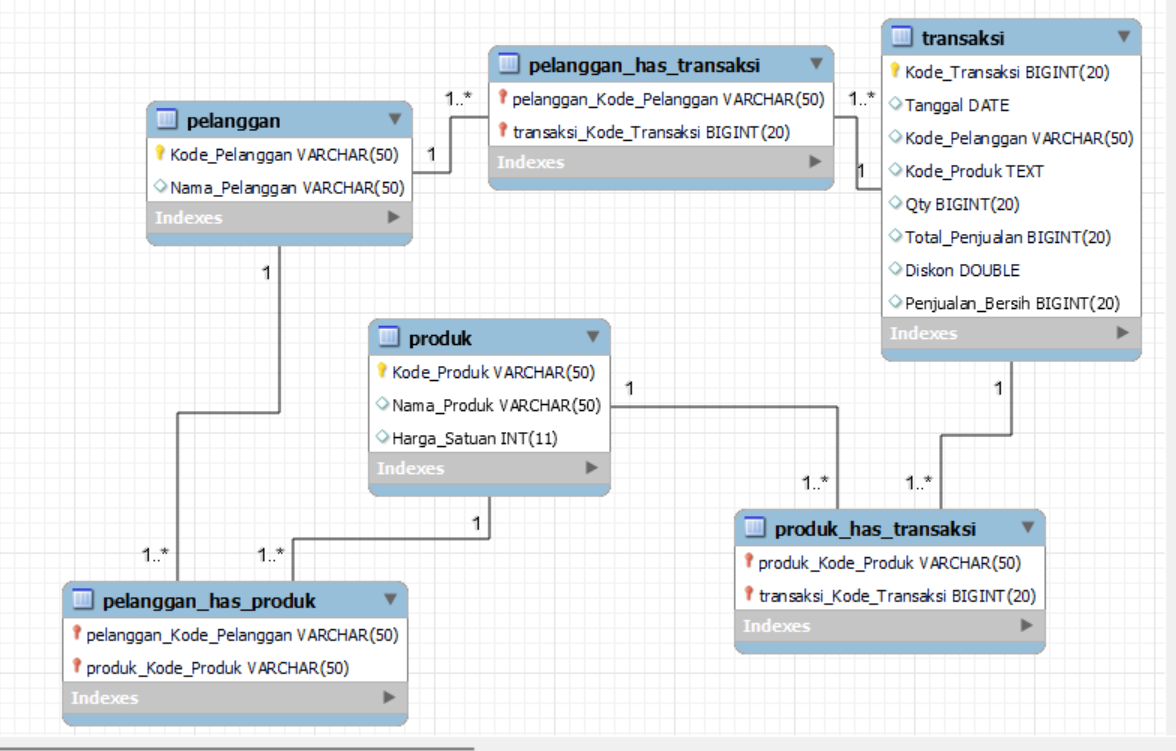

In [128]:
from IPython.display import display
from PIL import Image


path="D:\coolyeah\SEMESTER 4\BasDat\ERD PENJUALAN.png"
display(Image.open(path))

In [116]:

%%sql
INSERT INTO pelanggan (Kode_Pelanggan, Nama_Pelanggan) values
    ('DV-04', 'Toko Diva'),
    ('FR-05', 'Toko Frisca'),
    ('MR-06', 'Toko Marsha'),
    ('YK-07', 'Toko Yunike'),
    ('DT-08', 'Toko Dhita'),
    ('NZ-09', 'Toko Nazwa'),
    ('BR-10', 'Toko Berlin'),
    ('NA-11', 'Toko Nia'),
    ('PR-12', 'Toko Putri'),
    ('JL-13', 'Toko Jelli'),
    ('LA-14', 'Toko Lala'),
    ('NS-15', 'Toko Nissa'),
    ('LU-16', 'Toko Lulu'),
    ('RH-17', 'Toko Rahmi'),
    ('SV-18', 'Toko Silvi'),
    ('FV-19','Toko Flavorcake'),
    ('YM-20','Toko Yummybakery'),
    ('PE-21','Toko Pedesdower'),
    ('KI-22','Toko Keripikhero'),
    ('VA-23','Toko Veganheritage'),
    ('DT-24','Toko Dietlezat'),
    ('CI-25','Toko Cemilanteman'),
    ('ND-26','Toko Noodlestory'),
    ('HS-27','Toko Houseofsushi'),
    ('KC-28','Toko Kimchifood'),
    ('PZ-29','Toko Pizzacarte'),
    ('JA-30','Toko Jajanpasar'),
    ('VG-31','Toko Veggiebestie'),
    ('TI-32','Toko Tutifruity'),
    ('NT-33','Toko Ngetehduluyuk'),
    ('HL-34','Toko Hellocoffee');





 * mysql+mysqldb://root@localhost
31 rows affected.


[]

In [119]:


%%sql
INSERT INTO produk (Kode_Produk, Nama_Produk, Harga_Satuan) values
    ('S-01','Semen 1 Sak',200000),
    ('K-10','Kayu 10 Meter',324000),
    ('BS-01','Batu Split 1 Karung',154000),
    ('BT-01','Batu Bata 1 Buah',450),
    ('G-01','Genting 1 buah',500),
    ('K-01','Keramik 1 Kardus',321500),
    ('PS-01','Pasir 1 Karung',50000),
    ('KC-10','Kaca 10 mm',73000),
    ('C-10','Cat 10 Liter',73900),
    ('PK-01','Paku 1 Kardus',83500),
    ('PT-03','Pintu 3 Meter',202300),
    ('KL-10','Kabel Listrik 10 Meter',326300),
    ('T-10','Tiner 10 Liter',156300),
    ('AM-02','Amplas 2 Meter',2750),
    ('T-500','Toren 500 Liter',2800),
    ('B-16','Seng',323800),
    ('B-17','Talang',52300),
    ('B-18','Kawat',75300),
    ('B-19','Bendrat',76200),
    ('B-20','Plamir',85800),
    ('B-21','Lem Putih',204600),
    ('B-22','Bahan Mebel',328600),
    ('B-23','Mesin Air/ Pompa Air',158600),
    ('B-24','Bor',5050),
    ('B-25','Mata Bor',5100),
    ('B-26','Kompon',326100),
    ('B-27','Lem talang',54600),
    ('B-28','Batako',77600),
    ('B-29','Alat Listrik',78500),
    ('B-05','Asbes',88100);

 * mysql+mysqldb://root@localhost
30 rows affected.


[]

In [123]:


%%sql
INSERT INTO transaksi (Kode_Transaksi, Tanggal, Kode_Pelanggan, Kode_Produk, Qty, Total_Penjualan, Diskon, Penjualan_Bersih) values
    (16,'2023/08/01','NZ-09','S-01',12,2400000,0.1,2160000),
    (17,'2023/08/02','JL-13','BS-01',42,6468000,0.2,5174400),
    (18,'2023/08/03','LU-16','K-01',23,7394500,0.2,5915600),
    (19,'2023/08/04','PE-21','C-10',10,739000,0.1,665100),
    (20,'2023/08/05','DT-24','PT-03',4,809200,0.2,647360),
    (21,'2023/08/06','KC-28','AM-02',32,88000,0.2,70400),
    (22,'2023/08/07','VG-31','B-17',52,2719600,0.1,2447640),
    (23,'2023/08/08','NZ-09','B-21',31,6342600,0.2,5074080),
    (24,'2023/08/09','LA-14','B-28',38,2948800,0.2,2359040),
    (25,'2023/08/10','FV-19','BT-01',96,43200,0.1,38880),
    (26,'2023/08/11','VA-23','KC-10',43,3139000,0.2,2511200),
    (27,'2023/08/12','ND-26','KL-10',85,27735500,0.2,22188400),
    (28,'2023/08/13','PZ-29','B-20',63,5405400,0.1,4864860),
    (29,'2023/08/14','HL-34','B-24',54,272700,0.2,218160),
    (30,'2023/08/15','ND-26','B-26',32,10435200,0.2,8348160);

 * mysql+mysqldb://root@localhost
15 rows affected.


[]

In [129]:
%%sql

select * from pelanggan


 * mysql+mysqldb://root@localhost
31 rows affected.


Kode_Pelanggan,Nama_Pelanggan
BR-10,Toko Berlin
CI-25,Toko Cemilanteman
DT-08,Toko Dhita
DT-24,Toko Dietlezat
DV-04,Toko Diva
FR-05,Toko Frisca
FV-19,Toko Flavorcake
HL-34,Toko Hellocoffee
HS-27,Toko Houseofsushi
JA-30,Toko Jajanpasar


In [134]:
%%sql
select * from pelanggan where Nama_Pelanggan like '%D%'

 * mysql+mysqldb://root@localhost
7 rows affected.


Kode_Pelanggan,Nama_Pelanggan
DT-08,Toko Dhita
DT-24,Toko Dietlezat
DV-04,Toko Diva
KC-28,Toko Kimchifood
ND-26,Toko Noodlestory
NT-33,Toko Ngetehduluyuk
PE-21,Toko Pedesdower


In [153]:
%%sql
select * from produk
order by Kode_Produk

 * mysql+mysqldb://root@localhost
30 rows affected.


Kode_Produk,Nama_Produk,Harga_Satuan
AM-02,Amplas 2 Meter,2750
B-05,Asbes,88100
B-16,Seng,323800
B-17,Talang,52300
B-18,Kawat,75300
B-19,Bendrat,76200
B-20,Plamir,85800
B-21,Lem Putih,204600
B-22,Bahan Mebel,328600
B-23,Mesin Air/ Pompa Air,158600


In [154]:
%%sql
select * from produk where Harga_Satuan >= 100000

 * mysql+mysqldb://root@localhost
12 rows affected.


Kode_Produk,Nama_Produk,Harga_Satuan
B-16,Seng,323800
B-21,Lem Putih,204600
B-22,Bahan Mebel,328600
B-23,Mesin Air/ Pompa Air,158600
B-26,Kompon,326100
BS-01,Batu Split 1 Karung,154000
K-01,Keramik 1 Kardus,321500
K-10,Kayu 10 Meter,324000
KL-10,Kabel Listrik 10 Meter,326300
PT-03,Pintu 3 Meter,202300


In [155]:
%%sql

select * from transaksi

 * mysql+mysqldb://root@localhost
30 rows affected.


Kode_Transaksi,Tanggal,Kode_Pelanggan,Kode_Produk,Qty,Total_Penjualan,Diskon,Penjualan_Bersih
1,2023-01-03,NF-01,B-05,340,68000000,0.1,61200000
2,2023-05-10,AN-02,B-10,140,52500000,0.0,52500000
3,2023-05-10,CT-03,P-5,560,56000000,0.2,44800000
4,2023-01-03,CT-03,P-10,230,42550000,0.1,38295000
5,2023-05-10,AN-02,B-05,770,154000000,0.2,123200000
6,2023-08-13,NF-01,B-10,780,292500000,0.2,234000000
7,2023-05-10,AN-02,P-5,300,30000000,0.1,27000000
8,2023-08-13,NF-01,P-10,790,146150000,0.2,116920000
9,2023-01-03,CT-03,B-05,440,88000000,0.1,79200000
10,2023-08-09,AN-02,B-10,130,48750000,0.0,48750000


In [156]:
%%sql

select * from transaksi where month(Tanggal)='05'

 * mysql+mysqldb://root@localhost
6 rows affected.


Kode_Transaksi,Tanggal,Kode_Pelanggan,Kode_Produk,Qty,Total_Penjualan,Diskon,Penjualan_Bersih
2,2023-05-10,AN-02,B-10,140,52500000,0.0,52500000
3,2023-05-10,CT-03,P-5,560,56000000,0.2,44800000
5,2023-05-10,AN-02,B-05,770,154000000,0.2,123200000
7,2023-05-10,AN-02,P-5,300,30000000,0.1,27000000
12,2023-05-10,NF-01,P-10,120,22200000,0.0,22200000
15,2023-05-10,CT-03,P-10,250,46250000,0.1,41625000


In [162]:
%%sql
SELECT transaksi.Tanggal, transaksi.Kode_Pelanggan, pelanggan.Nama_Pelanggan,
            transaksi.Kode_Produk, produk.Nama_Produk, transaksi.Penjualan_Bersih
FROM transaksi 
INNER JOIN pelanggan ON transaksi.Kode_Pelanggan = pelanggan.Kode_Pelanggan
INNER JOIN produk ON transaksi.Kode_Produk = produk.Kode_Produk
where produk.Nama_Produk like'%batu%'
;

 * mysql+mysqldb://root@localhost
2 rows affected.


Tanggal,Kode_Pelanggan,Nama_Pelanggan,Kode_Produk,Nama_Produk,Penjualan_Bersih
2023-08-02,JL-13,Toko Jelli,BS-01,Batu Split 1 Karung,5174400
2023-08-10,FV-19,Toko Flavorcake,BT-01,Batu Bata 1 Buah,38880


In [157]:
%%sql
SELECT transaksi.Tanggal, transaksi.Kode_Pelanggan, pelanggan.Nama_Pelanggan,
            transaksi.Kode_Produk, produk.Nama_Produk, transaksi.Penjualan_Bersih
FROM transaksi 
INNER JOIN pelanggan ON transaksi.Kode_Pelanggan = pelanggan.Kode_Pelanggan
INNER JOIN produk ON transaksi.Kode_Produk = produk.Kode_Produk
where Penjualan_Bersih >= 1000000
;

 * mysql+mysqldb://root@localhost
10 rows affected.


Tanggal,Kode_Pelanggan,Nama_Pelanggan,Kode_Produk,Nama_Produk,Penjualan_Bersih
2023-08-01,NZ-09,Toko Nazwa,S-01,Semen 1 Sak,2160000
2023-08-02,JL-13,Toko Jelli,BS-01,Batu Split 1 Karung,5174400
2023-08-03,LU-16,Toko Lulu,K-01,Keramik 1 Kardus,5915600
2023-08-07,VG-31,Toko Veggiebestie,B-17,Talang,2447640
2023-08-08,NZ-09,Toko Nazwa,B-21,Lem Putih,5074080
2023-08-09,LA-14,Toko Lala,B-28,Batako,2359040
2023-08-11,VA-23,Toko Veganheritage,KC-10,Kaca 10 mm,2511200
2023-08-12,ND-26,Toko Noodlestory,KL-10,Kabel Listrik 10 Meter,22188400
2023-08-13,PZ-29,Toko Pizzacarte,B-20,Plamir,4864860
2023-08-15,ND-26,Toko Noodlestory,B-26,Kompon,8348160


In [161]:
%%sql
SELECT transaksi.Tanggal, transaksi.Kode_Pelanggan, pelanggan.Nama_Pelanggan,
            transaksi.Kode_Produk, produk.Nama_Produk, transaksi.Penjualan_Bersih
FROM transaksi 
INNER JOIN pelanggan ON transaksi.Kode_Pelanggan = pelanggan.Kode_Pelanggan
INNER JOIN produk ON transaksi.Kode_Produk = produk.Kode_Produk
where pelanggan.Nama_Pelanggan like '%Nood%'
;

 * mysql+mysqldb://root@localhost
2 rows affected.


Tanggal,Kode_Pelanggan,Nama_Pelanggan,Kode_Produk,Nama_Produk,Penjualan_Bersih
2023-08-12,ND-26,Toko Noodlestory,KL-10,Kabel Listrik 10 Meter,22188400
2023-08-15,ND-26,Toko Noodlestory,B-26,Kompon,8348160


In [150]:
%%sql
SELECT * 
FROM transaksi 
order by transaksi.Kode_Produk
;

 * mysql+mysqldb://root@localhost
30 rows affected.


Kode_Transaksi,Tanggal,Kode_Pelanggan,Kode_Produk,Qty,Total_Penjualan,Diskon,Penjualan_Bersih
21,2023-08-06,KC-28,AM-02,32,88000,0.2,70400
1,2023-01-03,NF-01,B-05,340,68000000,0.1,61200000
5,2023-05-10,AN-02,B-05,770,154000000,0.2,123200000
9,2023-01-03,CT-03,B-05,440,88000000,0.1,79200000
2,2023-05-10,AN-02,B-10,140,52500000,0.0,52500000
6,2023-08-13,NF-01,B-10,780,292500000,0.2,234000000
10,2023-08-09,AN-02,B-10,130,48750000,0.0,48750000
22,2023-08-07,VG-31,B-17,52,2719600,0.1,2447640
28,2023-08-13,PZ-29,B-20,63,5405400,0.1,4864860
23,2023-08-08,NZ-09,B-21,31,6342600,0.2,5074080


In [197]:
%%sql
CREATE USER 'user_root'@'localhost';
CREATE USER 'user_1'@'localhost';
CREATE USER 'user_2'@'localhost';

 * mysql+mysqldb://root@localhost
0 rows affected.
0 rows affected.
0 rows affected.


[]

In [198]:
%%sql
GRANT ALL PRIVILEGES ON penjualan.* TO 'user_root'@'localhost';
GRANT SELECT, INSERT, DELETE, DROP, ALTER ON penjualan.* TO 'user_1'@'localhost';
GRANT SELECT, UPDATE, DELETE, DROP ON penjualan.* TO 'user_2'@'localhost';

 * mysql+mysqldb://root@localhost
0 rows affected.
0 rows affected.
0 rows affected.


[]

In [199]:
%sql SHOW GRANTS FOR 'user_root'@'localhost';

 * mysql+mysqldb://root@localhost
2 rows affected.


Grants for user_root@localhost
GRANT USAGE ON *.* TO `user_root`@`localhost`
GRANT ALL PRIVILEGES ON `penjualan`.* TO `user_root`@`localhost`


In [200]:
%sql SHOW GRANTS FOR 'user_1'@'localhost';

 * mysql+mysqldb://root@localhost
2 rows affected.


Grants for user_1@localhost
GRANT USAGE ON *.* TO `user_1`@`localhost`
"GRANT SELECT, INSERT, DELETE, DROP, ALTER ON `penjualan`.* TO `user_1`@`localhost`"


In [201]:
%sql SHOW GRANTS FOR 'user_2'@'localhost';

 * mysql+mysqldb://root@localhost
2 rows affected.


Grants for user_2@localhost
GRANT USAGE ON *.* TO `user_2`@`localhost`
"GRANT SELECT, UPDATE, DELETE, DROP ON `penjualan`.* TO `user_2`@`localhost`"


In [ ]:
!{"C:\xampp\mysql\data\penjualan -u root -p penjualan > TB_kelompok10.sql"}